### **Detección de patentes con el método de Luvizon**

En este notebook se evalúa la detección de patentes usando el detector basado en gradientes y agrupamiento (Luvizon).  
Se cargan las anotaciones del ground truth, se corre el detector sobre cada frame del video, se calculan métricas básicas y se muestran ejemplos visuales.  
El foco es verificar qué tan bien funciona esta etapa aislada del pipeline.


### **Carga del proyecto y del ground truth**

En esta parte se configura el path para acceder a `src/`, se importan los módulos del proyecto y se carga el ground truth de patentes desde el XML del video 01.  
El resultado es un DataFrame con una fila por patente anotada: bounding box, frame y datos de radar (si los hubiera).


In [1]:
# ======================================================
# Celda 1: setup, paths, imports y Ground Truth patentes
# ======================================================
import sys
from pathlib import Path
import pandas as pd

PATENTES_ROOT = Path.cwd()          # estamos parados en .../patentes
SRC_DIR = PATENTES_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from paths import VIDEO01_MP4, XML_VEHICLES_PATH
from groundtruth import build_gt_plates_df
from metrics import run_luvizon_detection_on_gt, summarize_detection_metrics, summarize_detection_metrics
from visualization import (
    plot_gt_examples_grid,
    plot_gt_examples_2x1,
    plot_gt_single,
    plot_detection_examples_grid,
    plot_iou_histogram,
    plot_detection_examples_2x1,
    plot_detection_single,
    plot_table_as_image, 
    plot_gt_coverage_bars,
    plot_detection_summary_table,
)
from detector_luvizon import detect_plates_in_frame

print("SRC_DIR:", SRC_DIR)
print("VIDEO01_MP4:", VIDEO01_MP4)
print("XML_VEHICLES_PATH:", XML_VEHICLES_PATH)

df_gt = build_gt_plates_df(XML_VEHICLES_PATH)
print("Patentes con GT:", len(df_gt))
df_gt.head()

SRC_DIR: c:\Users\bianc\Vision\tpf\patentes\src
VIDEO01_MP4: C:\Users\bianc\Vision\tpf\data\video01\video.mp4
XML_VEHICLES_PATH: C:\Users\bianc\Vision\tpf\data\video01\vehicles.xml
Patentes con GT: 115


,frame,xml_idx,lane,x1,y1,x2,y2,w,h,radar_frame_start,radar_frame_end,radar_speed
0,58,0,1,493,696,545,737,52,41,NaN,NaN,NaN
1,71,1,3,1632,930,1738,965,106,35,71.0,111.0,56.65
2,107,2,3,1563,896,1666,923,103,27,107.0,147.0,53.74
3,187,3,2,880,926,988,954,108,28,187.0,227.0,52.13
4,245,4,3,1722,892,1825,924,103,32,245.0,285.0,49.06


### **Visualización de patentes anotadas**

Antes de evaluar el detector, se muestran algunas patentes reales anotadas en el ground truth para tener referencia visual de cómo se ven y cómo están ubicadas en el frame.  
Se eligen algunos frames al azar y se dibujan sus bounding boxes en verde.


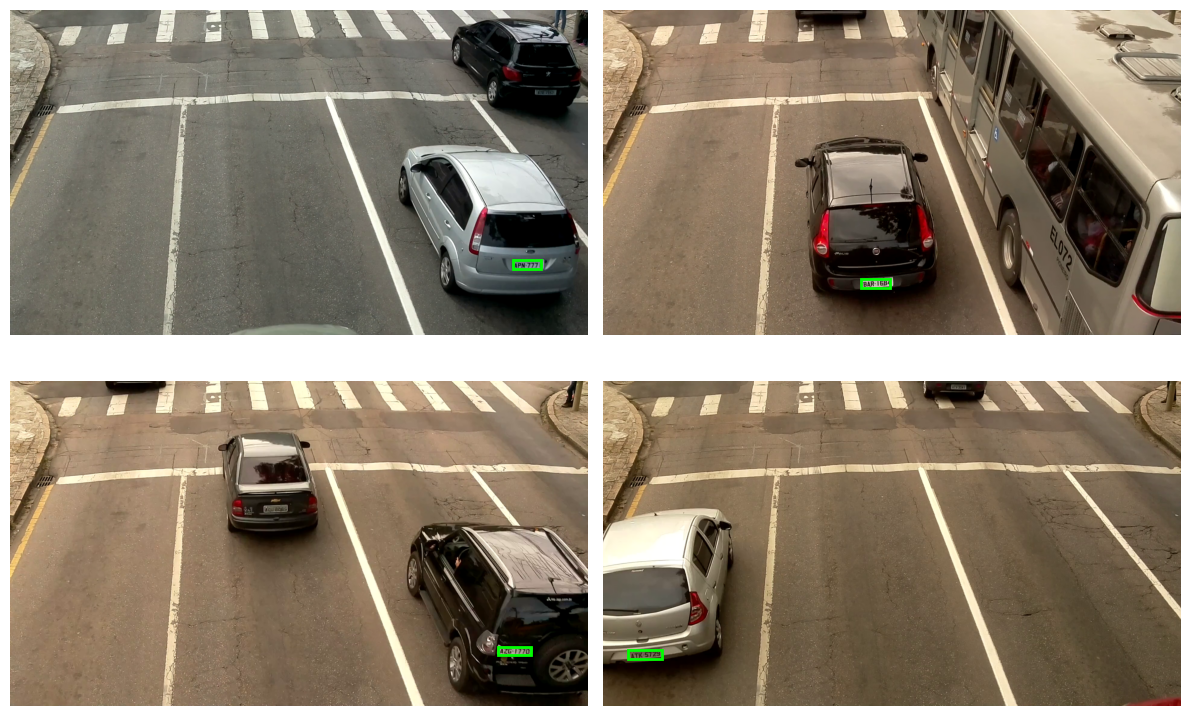

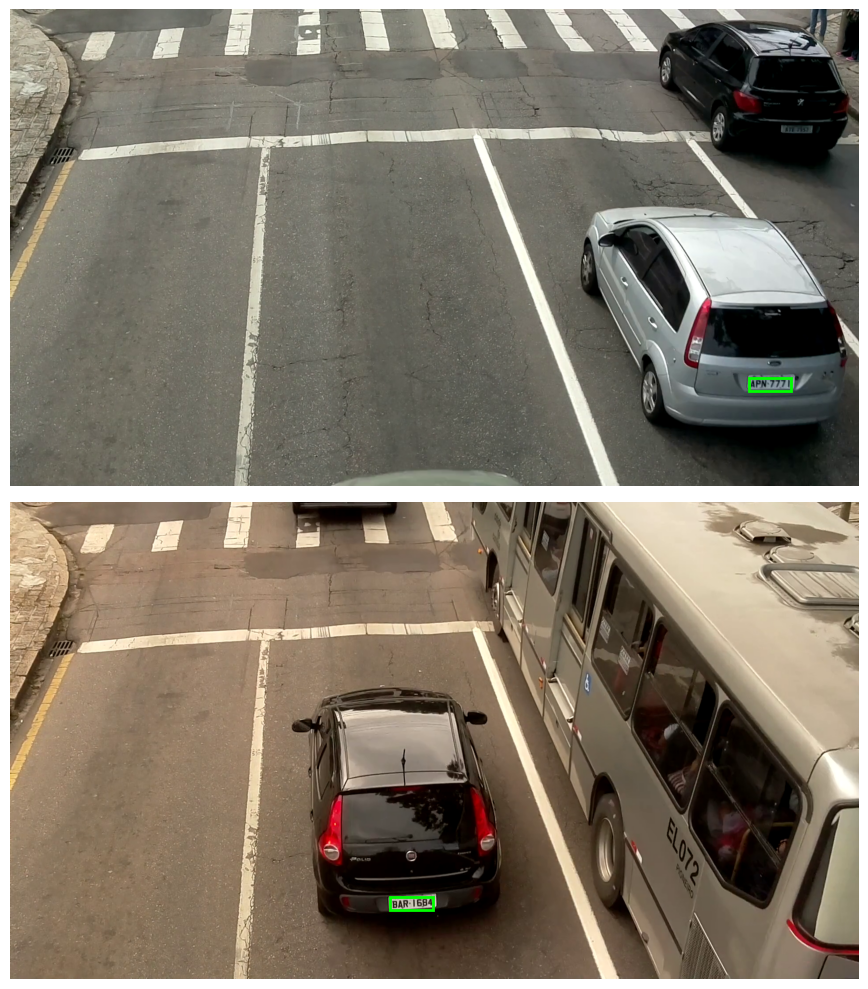

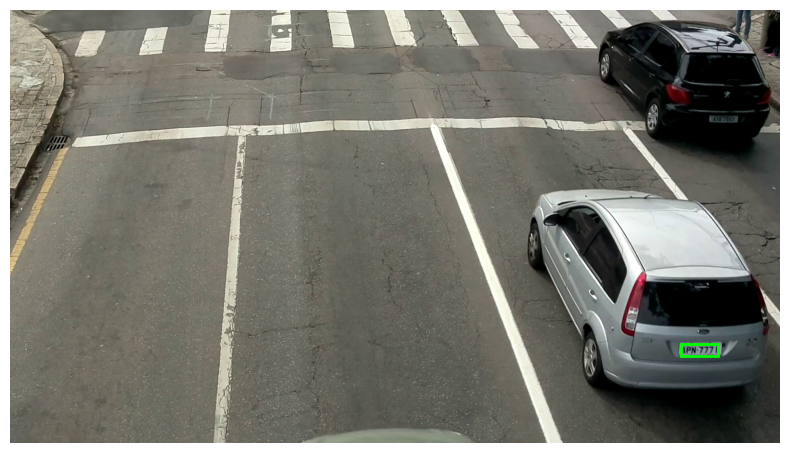

In [2]:
# ================================
# Celda 2: visualización de GT
# ================================
import numpy as np
import matplotlib.pyplot as plt

frames_example = df_gt["frame"].drop_duplicates().sample(4, random_state=0).tolist()

plot_gt_examples_grid(df_gt, VIDEO01_MP4, frames_example, figsize=(12, 8))

plot_gt_examples_2x1(df_gt, VIDEO01_MP4, frames_example, figsize=(10, 10))

plot_gt_single(df_gt, VIDEO01_MP4, frames_example[0], figsize=(8, 6))

### **Ejecutar el detector y obtener métricas**

Acá se corre el detector Luvizon sobre todos los frames que contienen una patente anotada.  
Para cada patente se busca la mejor predicción del detector y se calcula la IoU.  
Luego se computan estadísticas globales y por carril: porcentaje de detecciones con IoU ≥ 0.5, IoU promedio y cobertura del detector.

Esto permite evaluar de forma objetiva qué tan bien está funcionando la etapa de detección.

In [3]:
# ==============================================
# Celda 3: evaluación cuantitativa del detector
# ==============================================

df_eval = run_luvizon_detection_on_gt(
    df_gt,
    VIDEO01_MP4,
    rois_by_frame=None,
    max_frames=None,
    tau=2.0,
)

overall, lane_stats, per_detected = summarize_detection_metrics(df_eval)

Total frames video: 6918
Frames usados en evaluación: 115
Procesados 20/115 frames...
Procesados 40/115 frames...
Procesados 60/115 frames...
Procesados 80/115 frames...
Procesados 100/115 frames...


### **Distribución de IoU**

Se grafica un histograma de IoU para ver cómo se distribuyen los valores obtenidos por el detector.  
Valores cercanos a 0 indican que la detección no coincide con la posición real de la patente.  
Valores más altos significan que el detector está alineándose correctamente.

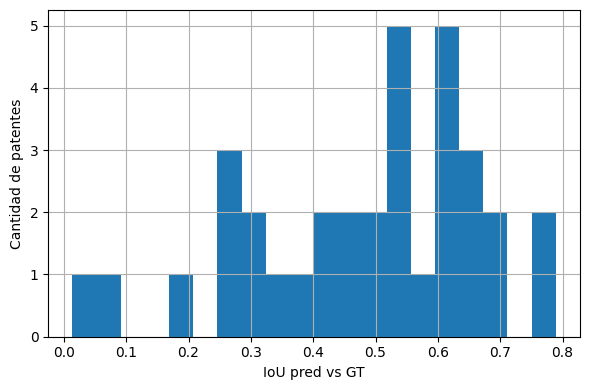

In [4]:
# =====================================
# Celda 4: histograma de IoU (sin título)
# =====================================
df_detected = df_eval[df_eval["has_pred"]]
plot_iou_histogram(df_detected, bins=20, figsize=(6, 4))

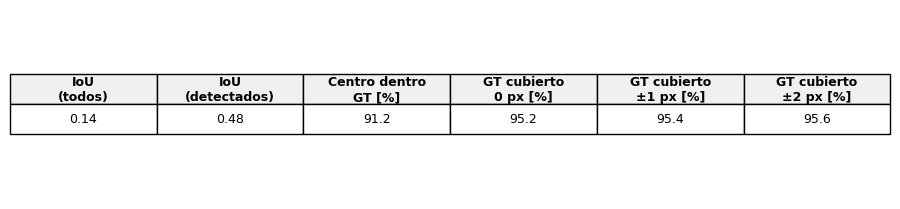

In [5]:
overall, lane_stats, per_det = summarize_detection_metrics(df_eval)

summary_row = {
    # OJO: ya no usamos with_pred_pct acá
    "mean_iou_all": overall["mean_iou_all"],
    "mean_iou_detected": per_det["mean_iou_detected"],
    "center_inside_pct": per_det["center_inside_pct"],
    "gt_covered_pct": per_det["mean_gt_covered_pct"],
    "gt_covered_pct_tol1": per_det["mean_gt_covered_pct_tol1"],
    "gt_covered_pct_tol2": per_det["mean_gt_covered_pct_tol2"],
}

df_det_summary = pd.DataFrame([summary_row])

plot_detection_summary_table(
    df_det_summary,
    figsize=(9, 2.2),
    fontsize=9,
)


### **Ejemplos visuales de detección**

Finalmente se muestran ejemplos de detección comparando la caja del ground truth (verde) con la predicha por el detector (rojo).  
Esto permite inspeccionar visualmente casos típicos del sistema, tanto correctos como incorrectos, y entender mejor su comportamiento real.


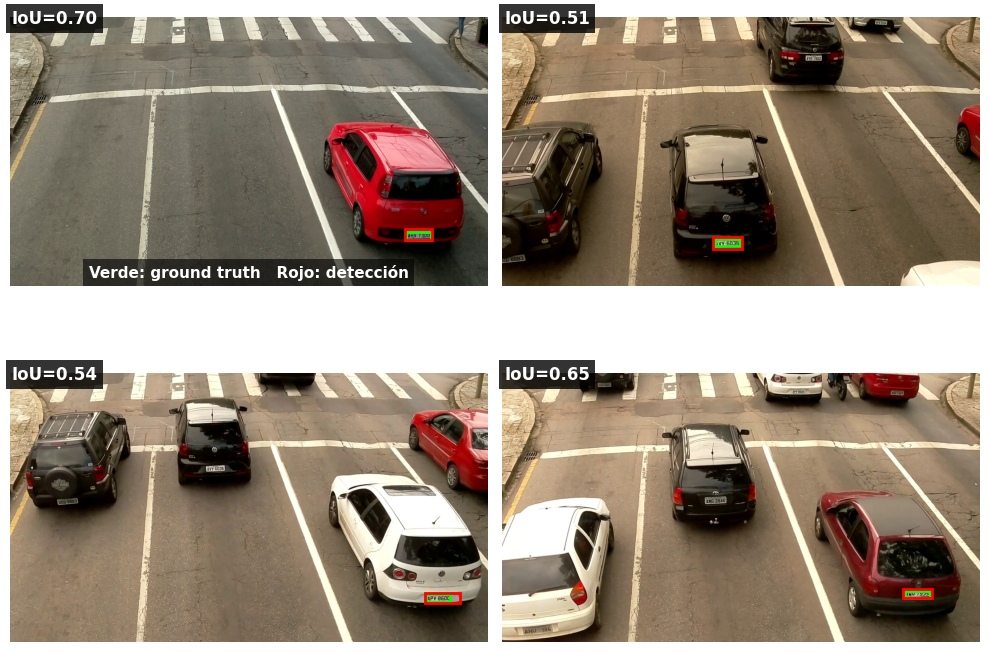

In [6]:
# ==========================================================
# Celda 5: 4 ejemplos de detección vs GT en una figura 2x2
# ==========================================================
df_det = df_eval[df_eval["has_pred"]]

good_df = df_det[(df_det["center_inside_gt"]) & (df_det["iou"] >= 0.5)]

if len(good_df) < 4:
    good_df = df_det.sort_values("iou", ascending=False).head(4)

good_examples = good_df.index.tolist()

plot_detection_examples_grid(
    df_eval,
    VIDEO01_MP4,
    example_indices=good_examples,
    figsize=(10, 8),
)

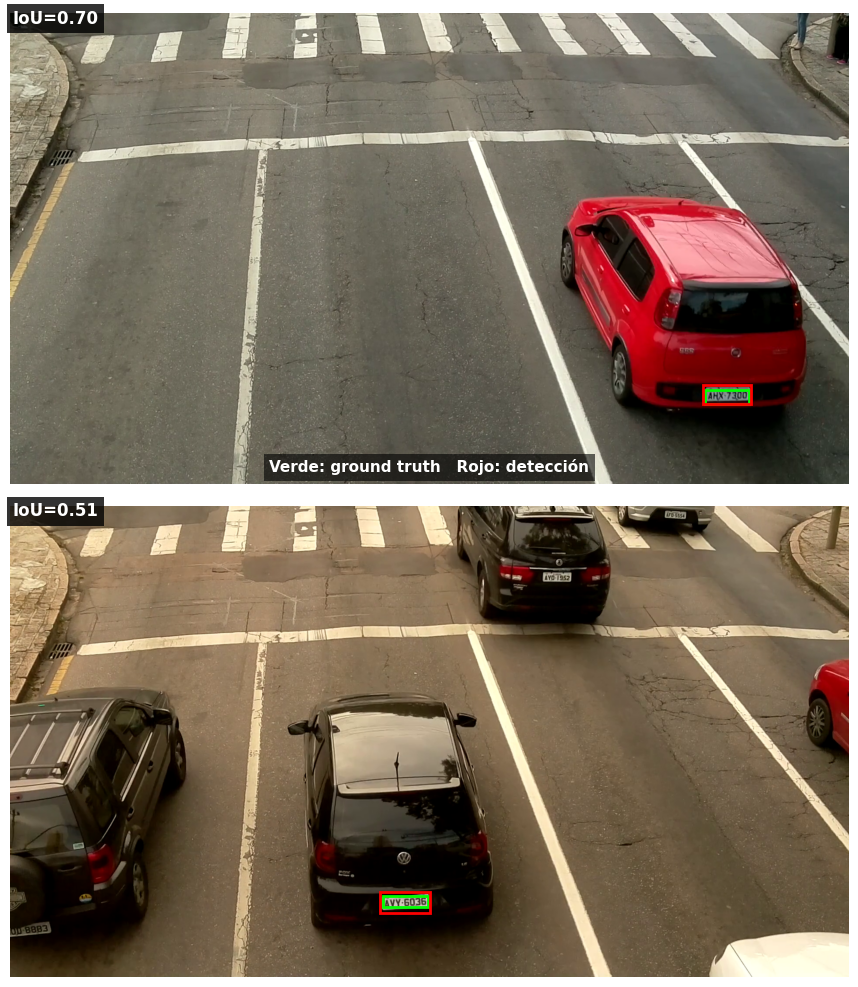

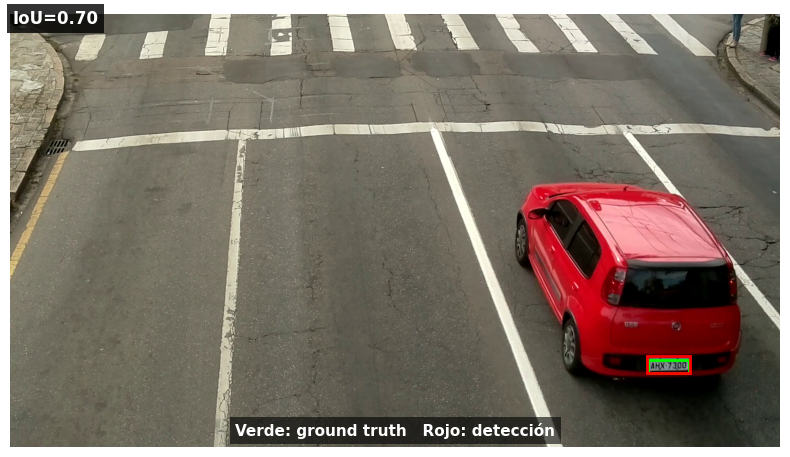

In [7]:
# ==========================================================
# Celda 6: variantes de visualización (2x1 y 1x1)
# ==========================================================
df_det = df_eval[df_eval["has_pred"]]

good_df = df_det[(df_det["center_inside_gt"]) & (df_det["iou"] >= 0.5)]
if len(good_df) < 4:
    good_df = df_det.sort_values("iou", ascending=False).head(4)

good_examples = good_df.index.tolist()

plot_detection_examples_2x1(
    df_eval,
    VIDEO01_MP4,
    example_indices=good_examples,
    figsize=(10, 10),
)

plot_detection_single(
    df_eval,
    VIDEO01_MP4,
    example_index=good_examples[0],
    figsize=(8, 6),
)